In [46]:
import pandas as pd
import numpy as np

In [45]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("saquib7hussain/k-mean-cluster-dataset")

print("Path to dataset files:", path)

print("\nFiles in dataset directory:")
for root, _, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

csv_files = [os.path.join(root, file) for root, _, files in os.walk(path) for file in files if file.endswith('.csv')]

if csv_files:
    data_file = csv_files[0]
    df = pd.read_csv(data_file)
    print(f"\nSuccessfully loaded '{os.path.basename(data_file)}' into a DataFrame.")
    print("First 5 rows of the dataset:")
    print(df.head())
else:
    print("\nNo CSV files found in the dataset directory.")

Path to dataset files: /root/.cache/kagglehub/datasets/saquib7hussain/k-mean-cluster-dataset/versions/1

Files in dataset directory:
/root/.cache/kagglehub/datasets/saquib7hussain/k-mean-cluster-dataset/versions/1/cluster_data.csv

Successfully loaded 'cluster_data.csv' into a DataFrame.
First 5 rows of the dataset:
   Feature 1  Feature 2
0   2.698582  -0.672960
1  -0.128113   4.355952
2   2.509049   5.773146
3  -1.518276   3.444886
4  -0.072283   2.883769


In [47]:
df.head()

,Feature 1,Feature 2
0,2.698582,-0.672960
1,-0.128113,4.355952
2,2.509049,5.773146
3,-1.518276,3.444886
4,-0.072283,2.883769


In [48]:
df.shape

(500, 2)

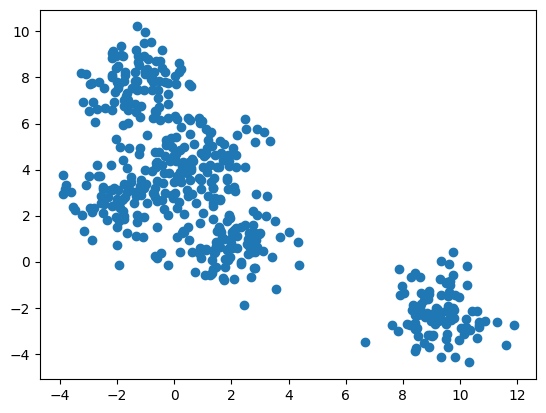

In [49]:
import matplotlib.pyplot as plt
plt.scatter(df['Feature 1'],df['Feature 2'])

In [50]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  km=KMeans(n_clusters=i)
  km.fit_predict(df)
  wcss.append(km.inertia_)

In [51]:
wcss

[14423.99557111693,
 4390.702977889529,
 2183.1288051012784,
 1351.8780782182982,
 880.1414064948569,
 805.0543636592536,
 749.5527464112336,
 650.2518899811926,
 600.2248200104755,
 558.5148062596379]

# finding value of K using the Elbow method

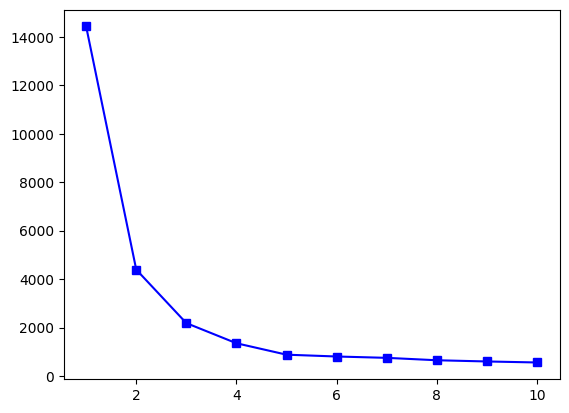

In [52]:
plt.plot(range(1,11),wcss, marker='s', color='blue')

In [53]:
X=df.iloc[:,:].values
km=KMeans(n_clusters=3)
y_mean=km.fit_predict(X)


In [54]:
y_mean

array([0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 0, 2, 0, 0, 0, 2,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 2, 2, 2, 1, 2, 0, 0,
       0, 0, 2, 0, 0, 1, 1, 2, 0, 0, 2, 0, 2, 2, 1, 0, 0, 2, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 0, 2, 0,
       0, 0, 0, 1, 1, 0, 2, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 1, 1, 1, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 1, 1, 1, 0,
       1, 2, 1, 2, 2, 2, 1, 0, 0, 1, 0, 0, 0, 2, 2, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 2, 0, 2, 0, 0, 1, 2, 1, 0, 2, 0, 0, 0, 0, 2,
       1, 1, 0, 1, 1, 1, 1, 0, 2, 0, 0, 0, 2, 1, 0, 1, 2, 1, 2, 0, 0, 0,
       0, 0, 2, 2, 2, 1, 0, 2, 2, 0, 0, 0, 1, 1, 1, 0, 1, 0, 2, 1, 0, 0,
       1, 2, 0, 0, 1, 1, 0, 2, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 2, 0, 1, 0,
       0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 2, 0, 0, 1, 0, 0, 2, 1, 0, 2, 1, 2,

In [55]:
X

array([[ 2.69858199e+00, -6.72959749e-01],
       [-1.28113261e-01,  4.35595241e+00],
       [ 2.50904929e+00,  5.77314610e+00],
       [-1.51827611e+00,  3.44488647e+00],
       [-7.22828865e-02,  2.88376939e+00],
       [ 9.15847989e+00, -2.02241838e+00],
       [ 2.81702219e-01,  4.15415279e+00],
       [ 8.86731348e+00, -1.60680112e+00],
       [ 1.69057398e+00,  1.05436752e+00],
       [ 1.57561171e+00,  1.51802196e+00],
       [-2.93648580e+00,  7.72299403e+00],
       [-2.54494589e+00,  2.84002751e+00],
       [ 3.41947985e-01,  3.94104616e+00],
       [-1.95317713e+00,  8.51543486e+00],
       [-1.06948841e+00,  1.95327025e+00],
       [ 8.52356487e+00, -2.29836088e+00],
       [-3.45525412e-01,  2.28597850e+00],
       [ 9.32420949e+00, -4.12539889e+00],
       [ 2.31515256e-01,  3.47734879e+00],
       [-2.85911567e+00,  9.49257572e-01],
       [ 1.76343016e+00,  1.36171448e-01],
       [ 1.02096538e+01, -2.85681022e+00],
       [-4.48706710e-01,  3.58697595e-01],
       [-3.

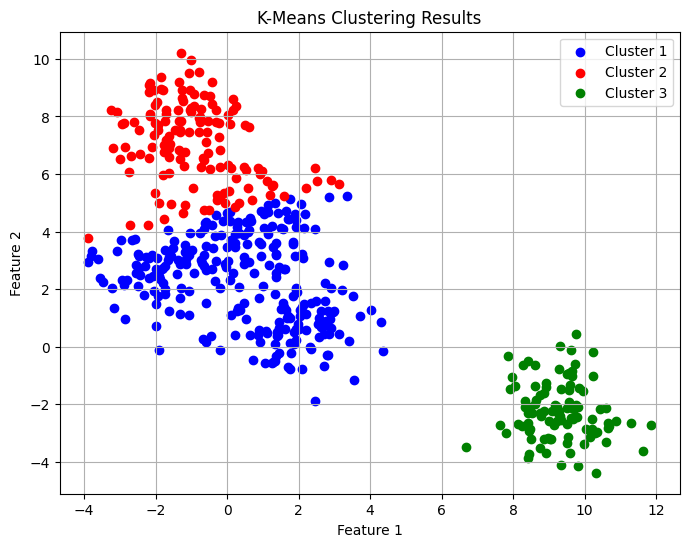

In [56]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y_mean == 0,0],X[y_mean==0,1],color='blue', label='Cluster 1')
plt.scatter(X[y_mean == 1,0],X[y_mean==1,1],color='red', label='Cluster 2')
plt.scatter(X[y_mean == 2,0],X[y_mean==2,1],color='green', label='Cluster 3')
plt.title('K-Means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()